In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
    'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

numerical = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
categorical = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
target = ['num']

In [3]:
FILEPATH = './processed.cleveland.data'
test_size = 0.2
seed = 42

df = pd.read_csv(FILEPATH, names=names)

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  num       303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [6]:
df['ca'].value_counts()

ca
0.0    176
1.0     65
2.0     38
3.0     20
?        4
Name: count, dtype: int64

In [7]:
df['thal'].value_counts()

thal
3.0    166
7.0    117
6.0     18
?        2
Name: count, dtype: int64

In [8]:
df['thal'].unique()

array(['6.0', '3.0', '7.0', '?'], dtype=object)

In [9]:
df['ca'].unique()

array(['0.0', '3.0', '2.0', '1.0', '?'], dtype=object)

## Thal
### Result of a Thallium stress test used to measure blood flow to the heart
3 Normal blood flow during exercise and rest\
6 Fixed defect - No blood flow in some parts of the heart during exercise and rest. Often indicates a past heart attack (scar tissue)\
7 Reversible defect - A blood flow defect is observed but is not constant; flow is abnormal during stress but normal at rest. Typically caused by ischemia, blockage that can be corrected

## ca
### Number of major vessels colored by flouroscopy

In [10]:
thal_map = {
    '6.0': 6,
    '3.0': 3,
    '7.0': 7,
    '?': np.nan
}

ca_map = {
    '0.0': 0,
    '3.0': 3,
    '2.0': 2,
    '1.0': 1,
    '?': np.nan
}

df['thal'] = df['thal'].map(thal_map)
df['ca'] = df['ca'].map(ca_map)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [12]:
X = df[names[:-1]]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    random_state=seed
)

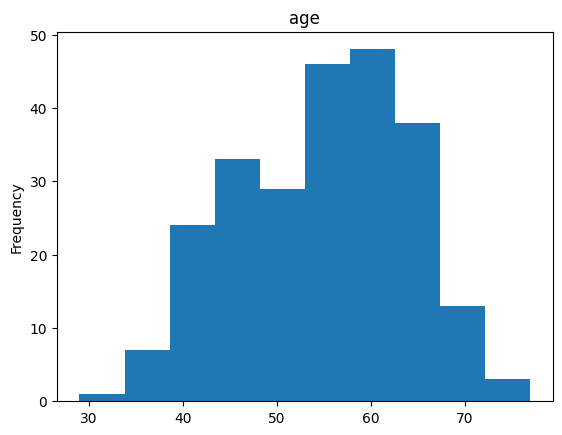

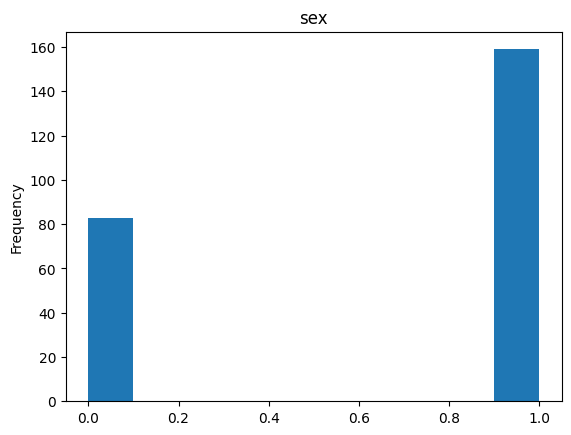

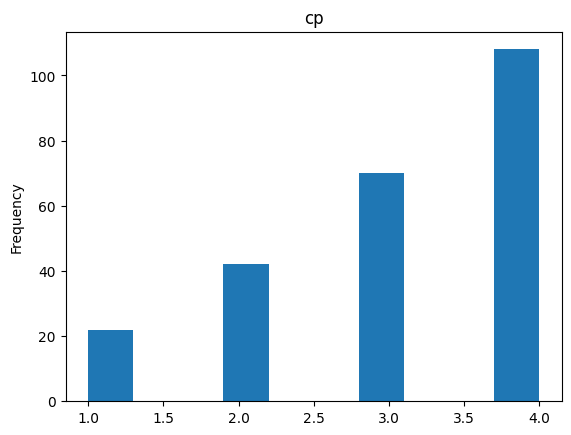

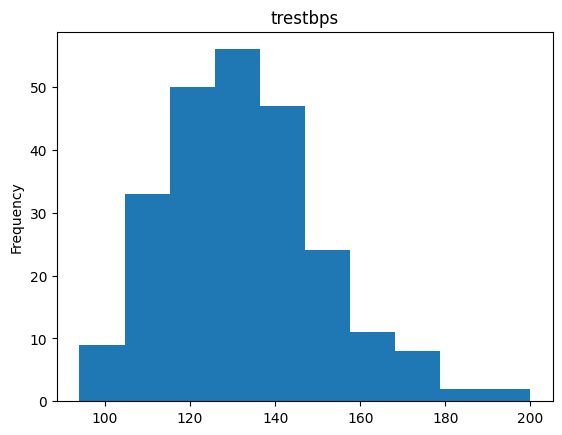

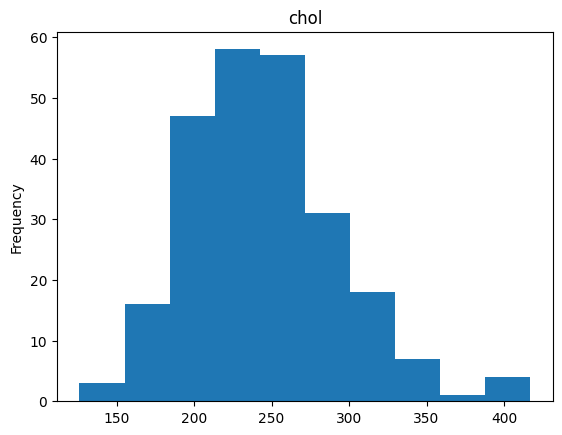

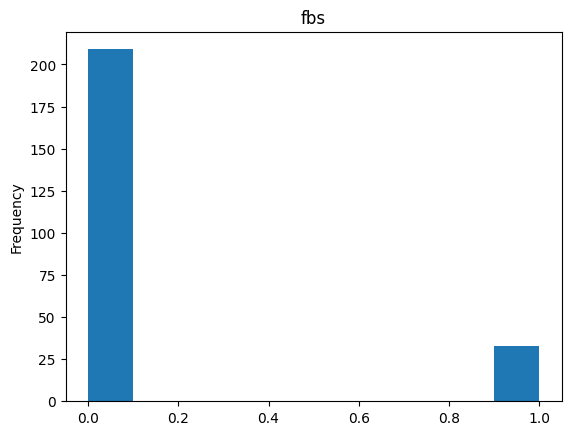

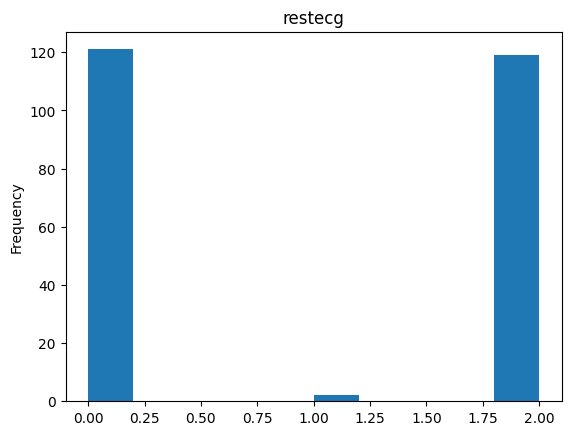

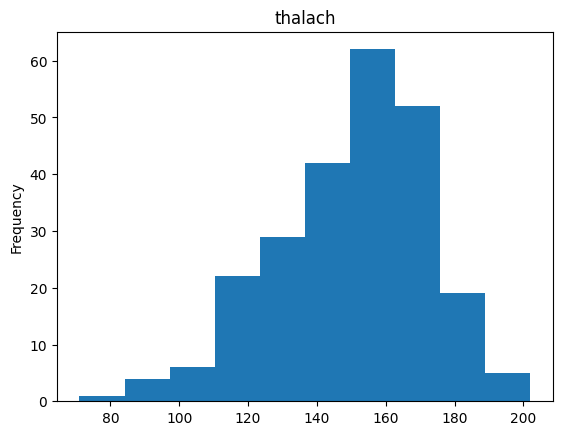

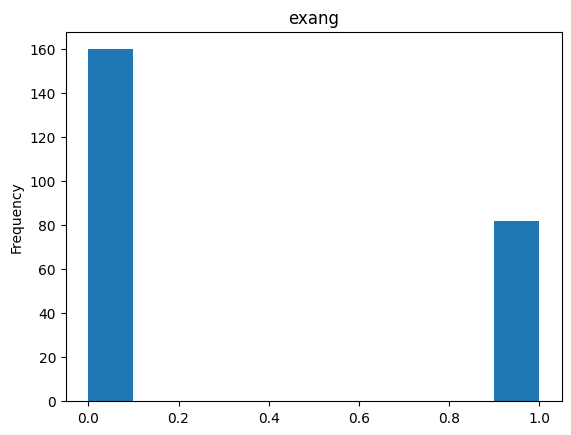

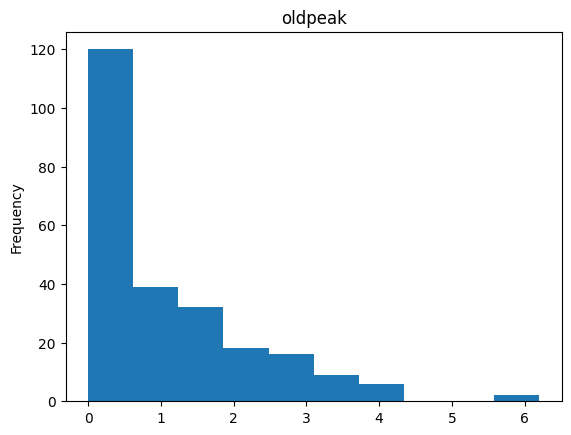

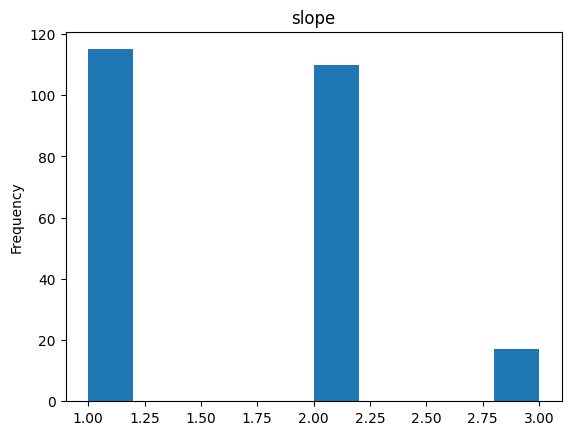

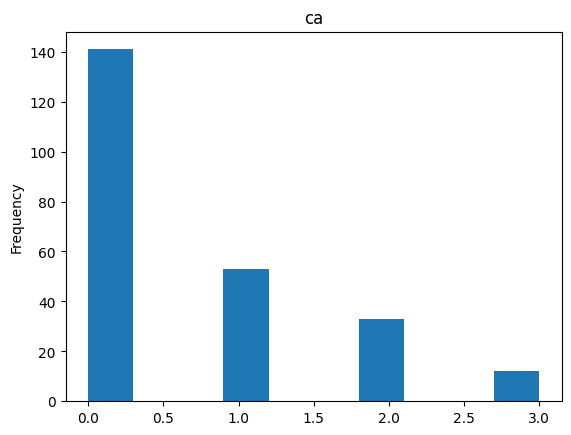

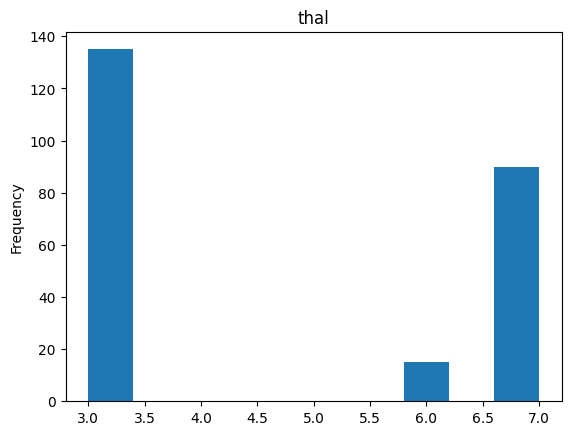

In [13]:
columns = X_train.columns
for col in columns:
    X_train[col].plot(kind='hist')
    plt.title(col)
    plt.show()

In [14]:
# sns.pairplot(X_train)
# plt.show()

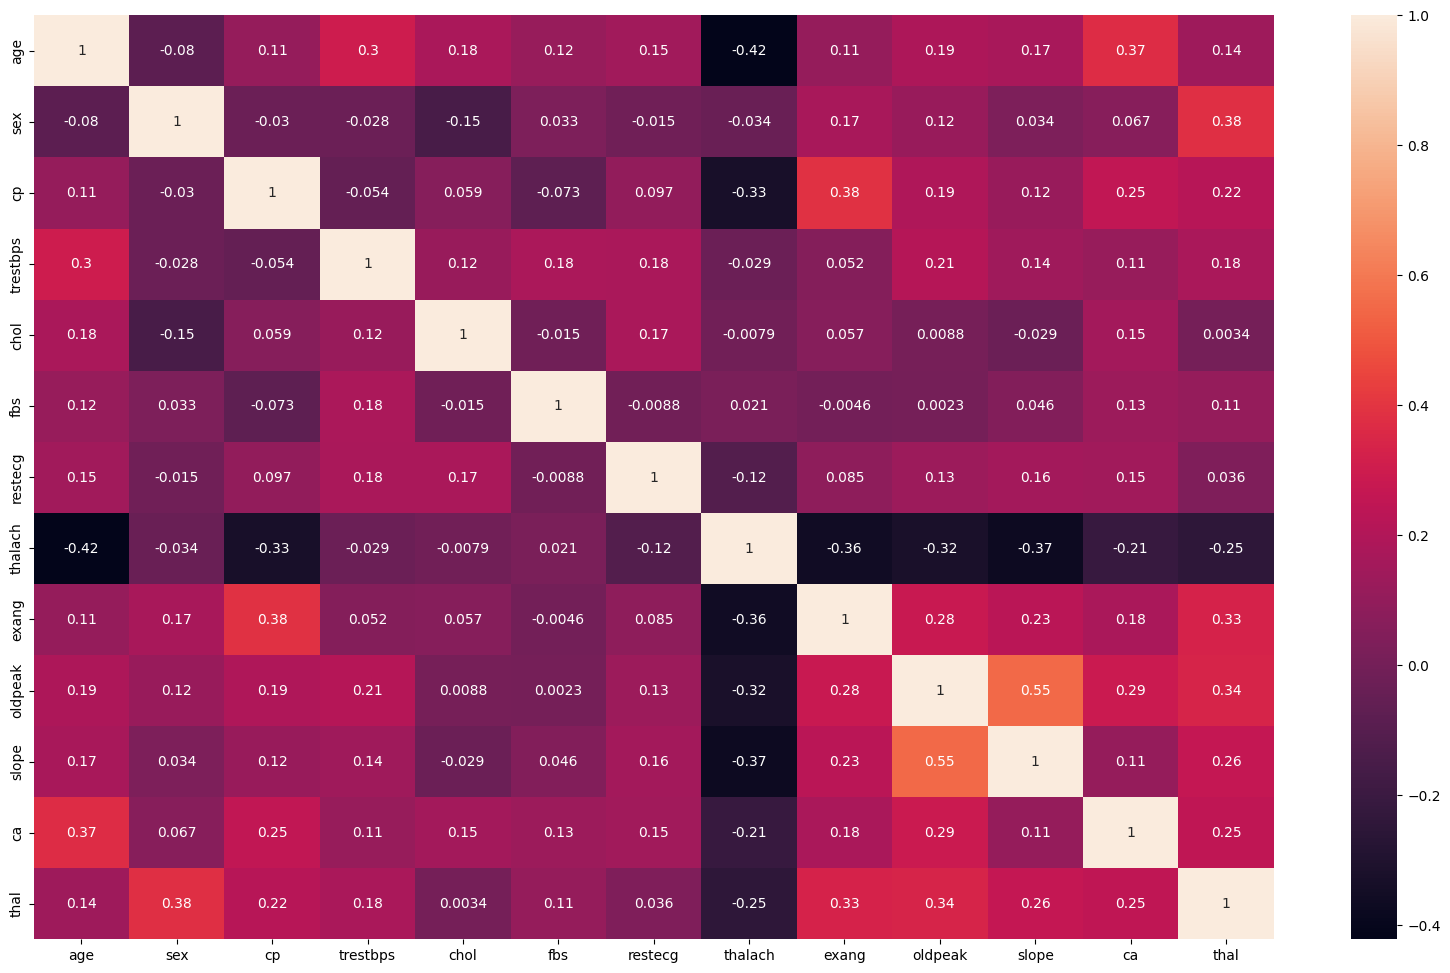

In [15]:
corr = X_train.corr()
plt.figure(figsize=(20,12))
sns.heatmap(corr, annot=True)
plt.show()

Sex, cp (chest pain), and fbs seem to have strong predictive power across the board

In [16]:
df.pivot_table(values='age', index='sex', columns='num', aggfunc='count', margins=True)

num,0,1,2,3,4,All
sex,,,,,,
0.0,72,9,7,7,2,97
1.0,92,46,29,28,11,206
All,164,55,36,35,13,303


In [17]:
df.pivot_table(values='age', index='cp', columns='num', aggfunc='count', margins=True)

num,0,1,2,3,4,All
cp,,,,,,
1.0,16.0,5.0,1.0,NaN,1.0,23
2.0,41.0,6.0,1.0,2.0,NaN,50
3.0,68.0,9.0,4.0,4.0,1.0,86
4.0,39.0,35.0,30.0,29.0,11.0,144
All,164.0,55.0,36.0,35.0,13.0,303


In [18]:
df.pivot_table(values='age', index='fbs', columns='num', aggfunc='count', margins=True)

num,0,1,2,3,4,All
fbs,,,,,,
0.0,141,51,27,27,12,258
1.0,23,4,9,8,1,45
All,164,55,36,35,13,303


In [19]:
df.pivot_table(values='age', index='restecg', columns='num', aggfunc='count', margins=True)

num,0,1,2,3,4,All
restecg,,,,,,
0.0,95.0,23.0,19.0,12.0,2.0,151
1.0,1.0,NaN,1.0,1.0,1.0,4
2.0,68.0,32.0,16.0,22.0,10.0,148
All,164.0,55.0,36.0,35.0,13.0,303


In [20]:
df.pivot_table(values='age', index='exang', columns='num', aggfunc='count', margins=True)

num,0,1,2,3,4,All
exang,,,,,,
0.0,141,30,14,12,7,204
1.0,23,25,22,23,6,99
All,164,55,36,35,13,303


<Axes: ylabel='Frequency'>

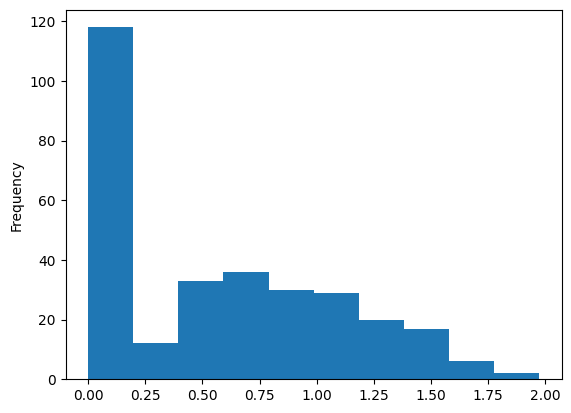

In [21]:
# Log transforming oldpeak gets something closer to normal, though still skewed
np.log(df['oldpeak'] + 1).plot(kind='hist')

<Axes: ylabel='Frequency'>

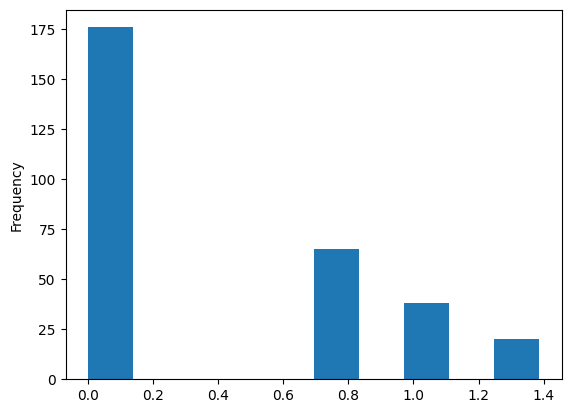

In [22]:
# Log transforming does not alter 'ca' sufficiently
np.log(df['ca'] + 1).plot(kind='hist')

In [23]:
df[categorical] = df[categorical].astype(str)
df = pd.get_dummies(df, dtype=int)
df

,age,trestbps,chol,thalach,oldpeak,ca,num,sex_0.0,sex_1.0,cp_1.0,...,restecg_2.0,exang_0.0,exang_1.0,slope_1.0,slope_2.0,slope_3.0,thal_3.0,thal_6.0,thal_7.0,thal_nan
0,63.0,145.0,233.0,150.0,2.3,0.0,0,0,1,1,...,1,1,0,0,0,1,0,1,0,0
1,67.0,160.0,286.0,108.0,1.5,3.0,2,0,1,0,...,1,0,1,0,1,0,1,0,0,0
2,67.0,120.0,229.0,129.0,2.6,2.0,1,0,1,0,...,1,0,1,0,1,0,0,0,1,0
3,37.0,130.0,250.0,187.0,3.5,0.0,0,0,1,0,...,0,1,0,0,0,1,1,0,0,0
4,41.0,130.0,204.0,172.0,1.4,0.0,0,1,0,0,...,1,1,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,110.0,264.0,132.0,1.2,0.0,1,0,1,1,...,0,1,0,0,1,0,0,0,1,0
299,68.0,144.0,193.0,141.0,3.4,2.0,2,0,1,0,...,0,1,0,0,1,0,0,0,1,0
300,57.0,130.0,131.0,115.0,1.2,1.0,3,0,1,0,...,0,0,1,0,1,0,0,0,1,0
301,57.0,130.0,236.0,174.0,0.0,1.0,1,1,0,0,...,1,1,0,0,1,0,1,0,0,0


In [24]:
def preprocess(df):
    # Converting ca to numeric values, filling '?' with median
    df['ca'] = df['ca'].map(ca_map)
    df['ca'] = df['ca'].fillna(df['ca'].median())

    # Log transforming oldpeak
    df['oldpeak'] = np.log(df['oldpeak'] + 1)

    # One-hot encoding categorical data
    df[categorical] = df[categorical].astype(str)
    df = pd.get_dummies(df, dtype=int)

    # Scaling numerical data
    scaler = StandardScaler()
    df[numerical] = scaler.fit_transform(df[numerical])

    return df